# Chapter 13 — Classical Learning & Unsupervised Analysis

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch13_classical_learning.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/ch13_classical_learning.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch13_classical_learning.ipynb)

> **Motivating question.** Given a clean feature matrix, which learner should score the sleep — and can structure be found without labels?

## What this notebook demonstrates

- k-NN, SVM (kernel trick), decision trees, random forests
- Bagging and out-of-bag error
- k-means and hierarchical clustering
- PCA vs feature selection
- The 'fair fight': same split, same features, same metrics

## What you'll do

You'll train k-NN, an SVM, and a random forest on the identical split and features — the "fair fight" — and compare their decision boundaries, then run k-means, hierarchical clustering, and PCA on the same data.

## Runs in

| Platform | Status |
|---|---|
| **View (static)** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | reduced (a lighter path runs in the browser) |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [2]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

CH = 13

STAGES = ["W", "N2", "N3", "REM"]
SCLR = [bs.C["orange"], bs.C["blue"], bs.C["purple"], bs.C["green"]]


def make_2d(n_per=90, seed=0):
    """Four sleep-like classes in a 2-D (delta-power, fast-power) feature plane.

    Deliberately overlapping so that different learners draw visibly different
    boundaries — the point of the figure.
    """
    rng = np.random.default_rng(seed)
    # (mean_x, mean_y): x ~ 'slow/delta power', y ~ 'fast/beta+spindle power'
    centres = np.array([[2.4, 2.3],    # W  (high fast, moderate slow)
                        [0.6, 0.9],    # N2 (mixed, central)
                        [-1.8, -0.4],  # N3 (very high delta -> low on x here)
                        [1.6, -1.6]])  # REM
    covs = [0.9, 1.0, 0.8, 0.9]
    X, y = [], []
    for k, (c, s) in enumerate(zip(centres, covs)):
        X.append(rng.normal(c, s, size=(n_per, 2)))
        y.append(np.full(n_per, k))
    return np.vstack(X), np.concatenate(y)


def make_highd(n_per=120, seed=1):
    """8-D feature set: a few informative axes + several noise axes."""
    rng = np.random.default_rng(seed)
    means = np.array([
        [2.2, 0.0, 1.0, 0.0],   # W
        [0.4, 1.4, 0.2, 0.0],   # N2
        [-1.6, 0.0, -0.6, 1.4], # N3
        [0.9, 1.0, 1.6, 0.2],   # REM
    ])
    X, y = [], []
    for k in range(4):
        core = means[k] + rng.normal(0, 0.9, size=(n_per, 4))
        noise = rng.normal(0, 1.0, size=(n_per, 4))      # 4 uninformative axes
        X.append(np.hstack([core, noise]))
        y.append(np.full(n_per, k))
    return np.vstack(X), np.concatenate(y)

## 13.1  boundaries

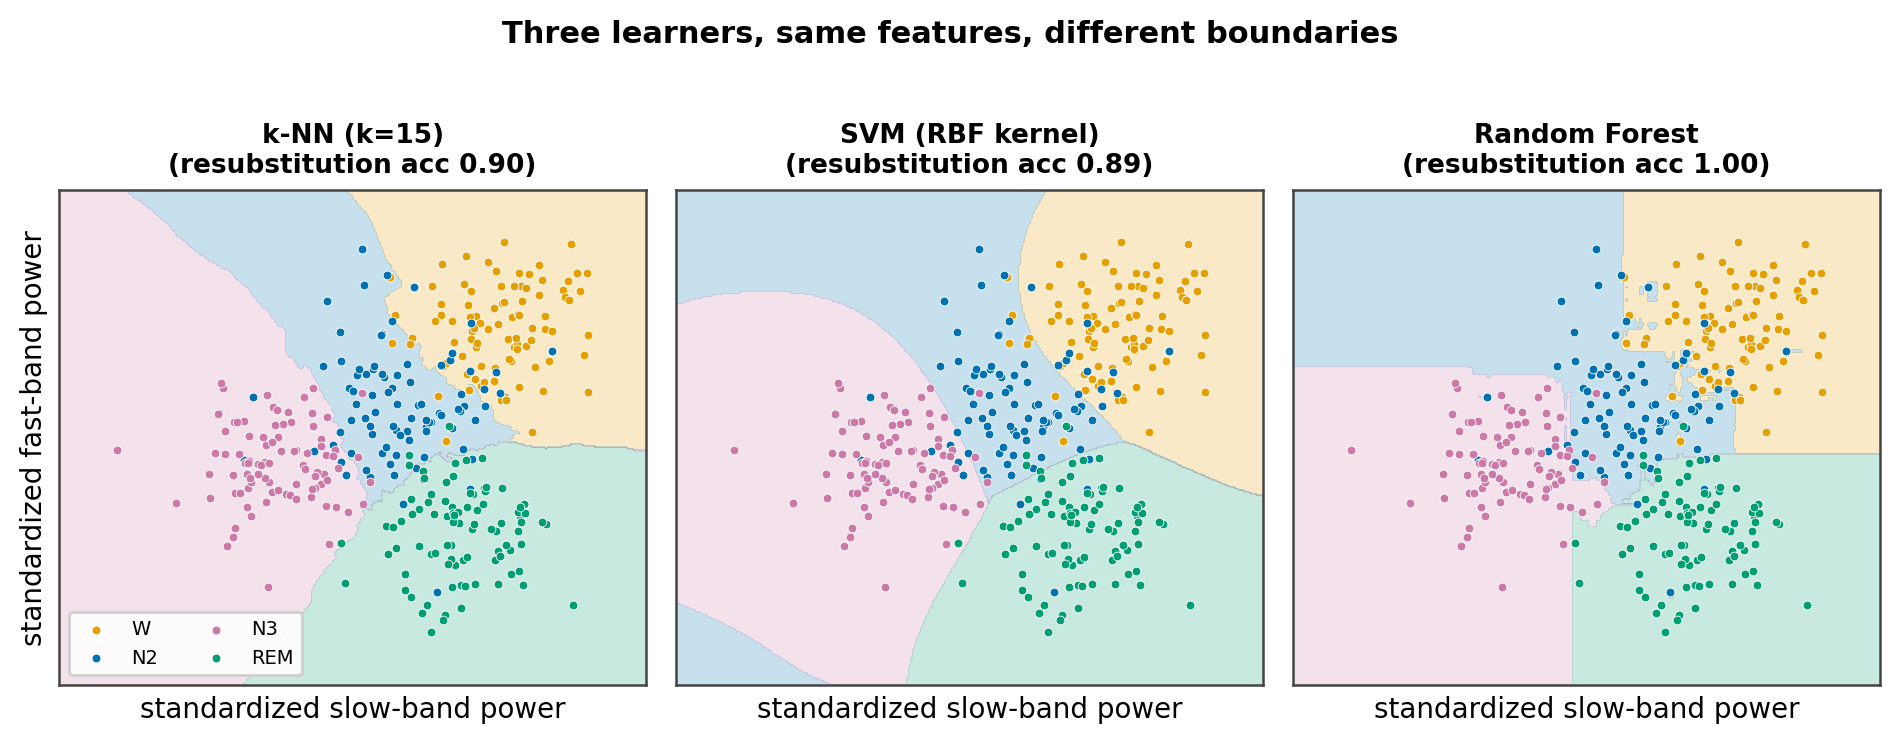

In [3]:
X, y = make_2d(seed=0)
sc = StandardScaler().fit(X)
Xs = sc.transform(X)

models = [
    ("k-NN (k=15)", KNeighborsClassifier(n_neighbors=15)),
    ("SVM (RBF kernel)", SVC(kernel="rbf", C=2.0, gamma="scale")),
    ("Random Forest", RandomForestClassifier(n_estimators=200,
                                              max_depth=None, random_state=0)),
]

# mesh in standardized space
x0, x1 = Xs[:, 0].min() - 0.6, Xs[:, 0].max() + 0.6
y0, y1 = Xs[:, 1].min() - 0.6, Xs[:, 1].max() + 0.6
xx, yy = np.meshgrid(np.linspace(x0, x1, 300), np.linspace(y0, y1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

from matplotlib.colors import ListedColormap
fill = ListedColormap([c for c in SCLR])

fig, axes = bs.newfig(w=9.6, h=3.6, ncols=3)
for ax, (name, clf) in zip(axes, models):
    clf.fit(Xs, y)
    Z = clf.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.22, cmap=fill, levels=[-.5, .5, 1.5, 2.5, 3.5])
    for k in range(4):
        m = y == k
        ax.scatter(Xs[m, 0], Xs[m, 1], s=10, color=SCLR[k],
                   edgecolor="white", linewidth=0.3, label=STAGES[k])
    acc = clf.score(Xs, y)
    ax.set_title(f"{name}\n(resubstitution acc {acc:.2f})", fontsize=9.5)
    ax.set_xlabel("standardized slow-band power")
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(False)
axes[0].set_ylabel("standardized fast-band power")
axes[0].legend(loc="lower left", fontsize=7, ncol=2, framealpha=0.9)
fig.suptitle("Three learners, same features, different boundaries",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 13.2  clustering

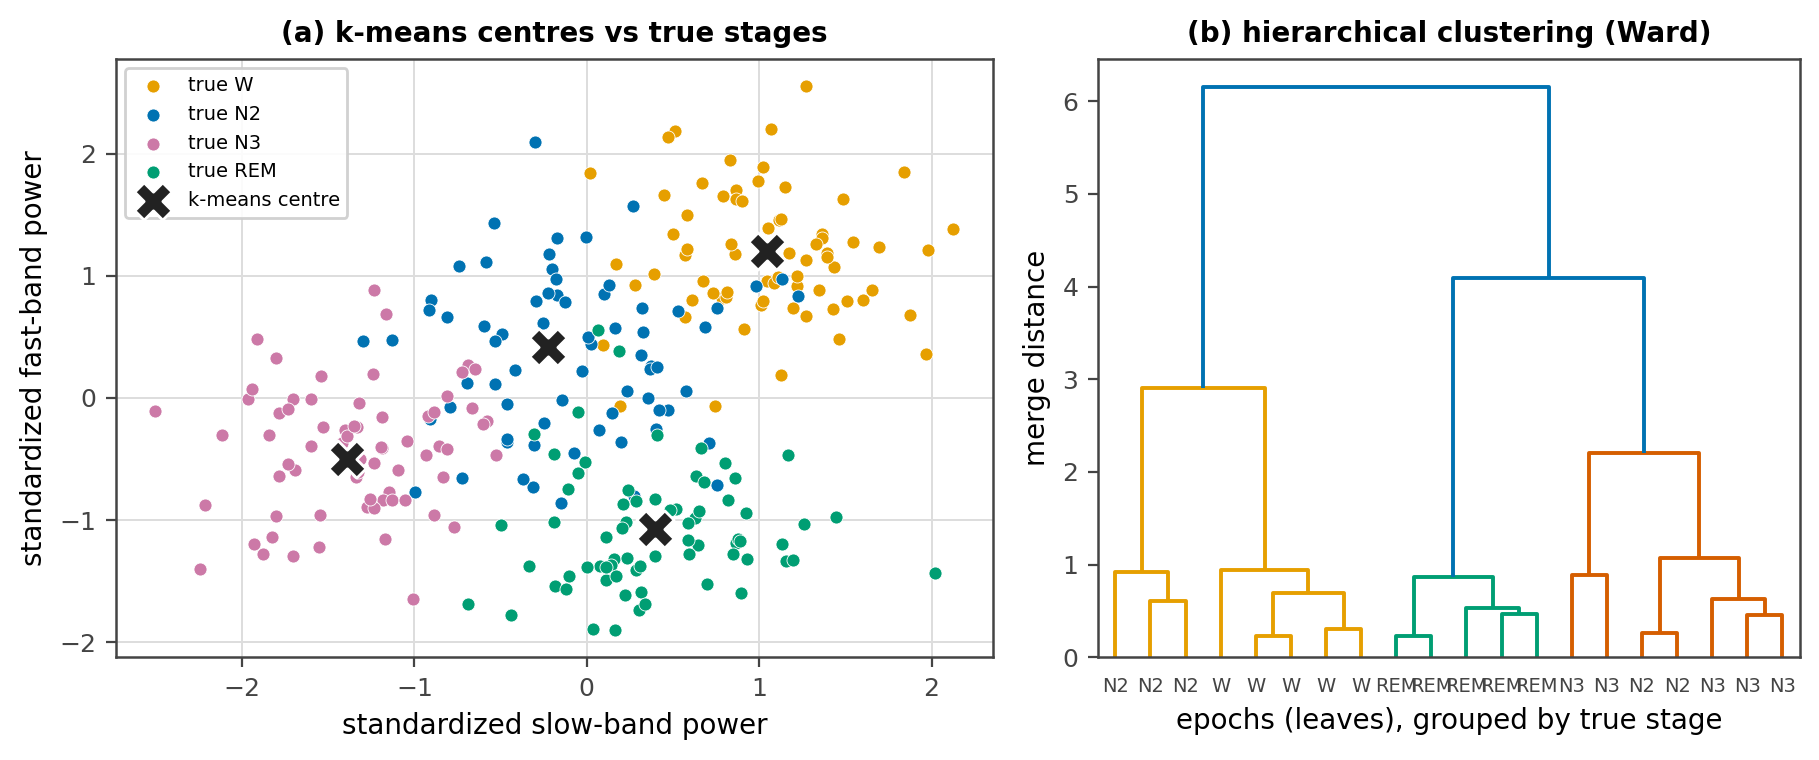

In [4]:
X, y = make_2d(n_per=70, seed=2)
sc = StandardScaler().fit(X)
Xs = sc.transform(X)

km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(Xs)
labels = km.labels_

fig, axes = bs.newfig(w=9.2, h=3.9, ncols=2,
                      gridspec_kw={"width_ratios": [1.25, 1.0]})

# (a) true classes as colour, k-means cluster as marker shape
markers = ["o", "s", "^", "D"]
for k in range(4):
    m = y == k
    axes[0].scatter(Xs[m, 0], Xs[m, 1], s=22, color=SCLR[k],
                    edgecolor="white", linewidth=0.3, label=f"true {STAGES[k]}")
# cluster centres
axes[0].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                s=180, marker="X", color=bs.C["black"], edgecolor="white",
                linewidth=1.0, label="k-means centre", zorder=5)
axes[0].set_title("(a) k-means centres vs true stages", fontsize=10)
axes[0].set_xlabel("standardized slow-band power")
axes[0].set_ylabel("standardized fast-band power")
axes[0].legend(loc="upper left", fontsize=7, ncol=1, framealpha=0.9)

# (b) hierarchical clustering dendrogram on class centroids + a few points
#     use a small representative sample so the tree is readable
rng = np.random.default_rng(7)
idx = np.concatenate([rng.choice(np.where(y == k)[0], 5, replace=False)
                      for k in range(4)])
Xsmall = Xs[idx]
lab = [STAGES[k] for k in y[idx]]
Z = linkage(Xsmall, method="ward")
dendrogram(Z, labels=lab, ax=axes[1], color_threshold=0.6 * Z[:, 2].max(),
           leaf_font_size=7)
axes[1].set_title("(b) hierarchical clustering (Ward)", fontsize=10)
axes[1].set_ylabel("merge distance")
axes[1].set_xlabel("epochs (leaves), grouped by true stage")
axes[1].grid(False)
plt.tight_layout()
plt.show()

## 13.3  pca

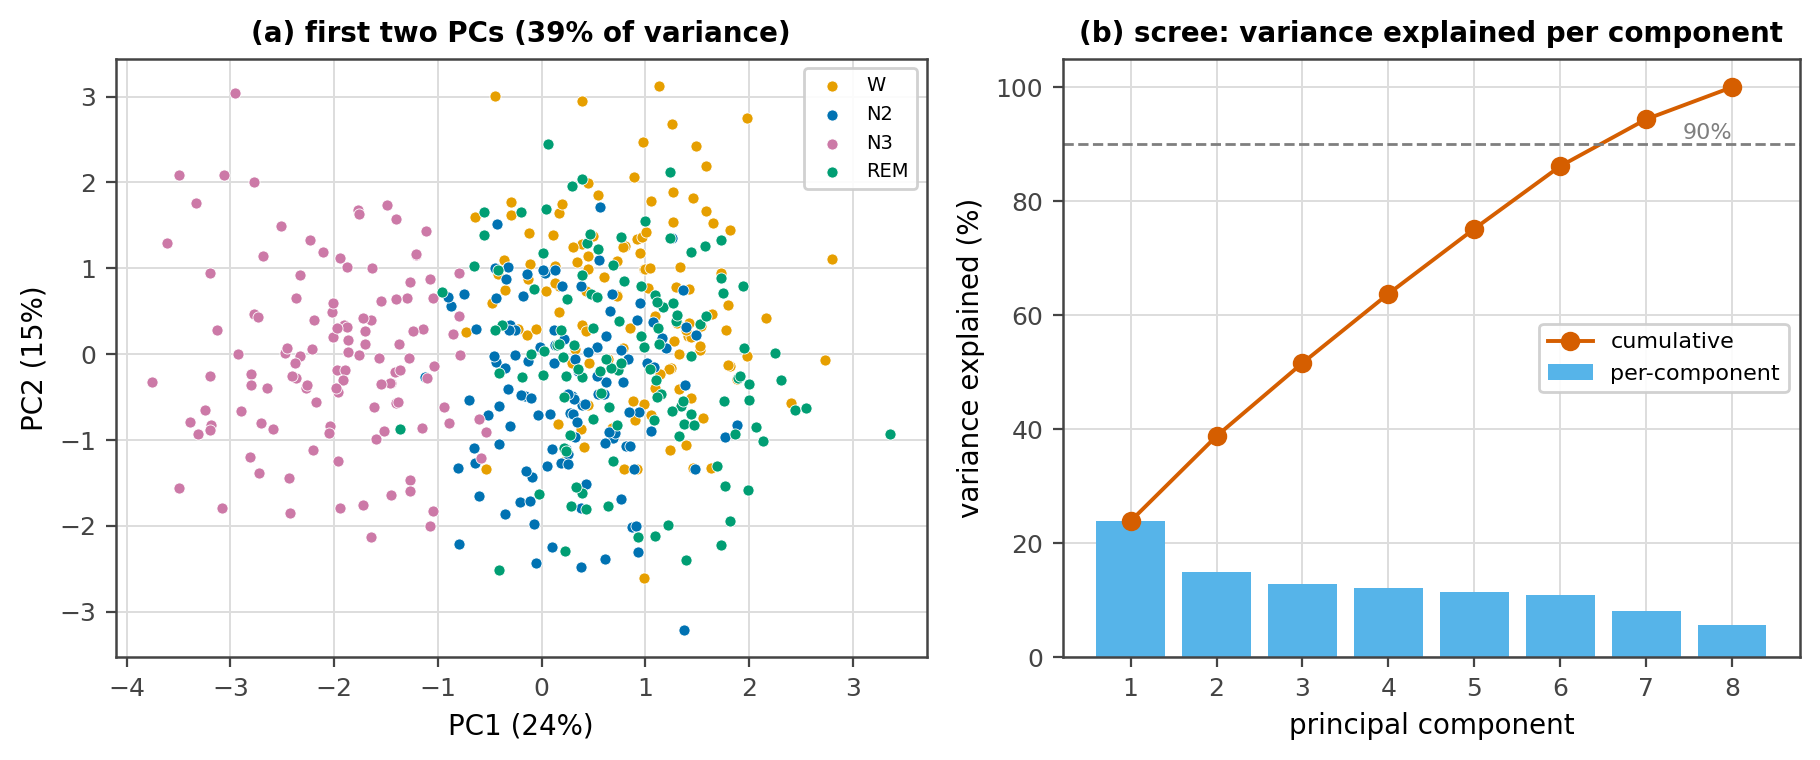

In [5]:
X, y = make_highd(seed=3)
Xs = StandardScaler().fit_transform(X)
p = PCA().fit(Xs)
Z = p.transform(Xs)
evr = p.explained_variance_ratio_

fig, axes = bs.newfig(w=9.2, h=3.9, ncols=2,
                      gridspec_kw={"width_ratios": [1.1, 1.0]})

for k in range(4):
    m = y == k
    axes[0].scatter(Z[m, 0], Z[m, 1], s=16, color=SCLR[k],
                    edgecolor="white", linewidth=0.3, label=STAGES[k])
axes[0].set_title(f"(a) first two PCs "
                  f"({100*(evr[0]+evr[1]):.0f}% of variance)", fontsize=10)
axes[0].set_xlabel(f"PC1 ({100*evr[0]:.0f}%)")
axes[0].set_ylabel(f"PC2 ({100*evr[1]:.0f}%)")
axes[0].legend(loc="best", fontsize=7)

comps = np.arange(1, len(evr) + 1)
axes[1].bar(comps, 100 * evr, color=bs.C["sky"], label="per-component")
axes[1].plot(comps, 100 * np.cumsum(evr), "o-", color=bs.C["red"],
             label="cumulative")
axes[1].axhline(90, color=bs.C["grey"], ls="--", lw=1.0)
axes[1].text(len(evr), 91, "90%", fontsize=8, color=bs.C["grey"], ha="right")
axes[1].set_title("(b) scree: variance explained per component", fontsize=10)
axes[1].set_xlabel("principal component")
axes[1].set_ylabel("variance explained (%)")
axes[1].set_xticks(comps)
axes[1].legend(loc="center right", fontsize=8)
plt.tight_layout()
plt.show()

## 13.4  learner comparison

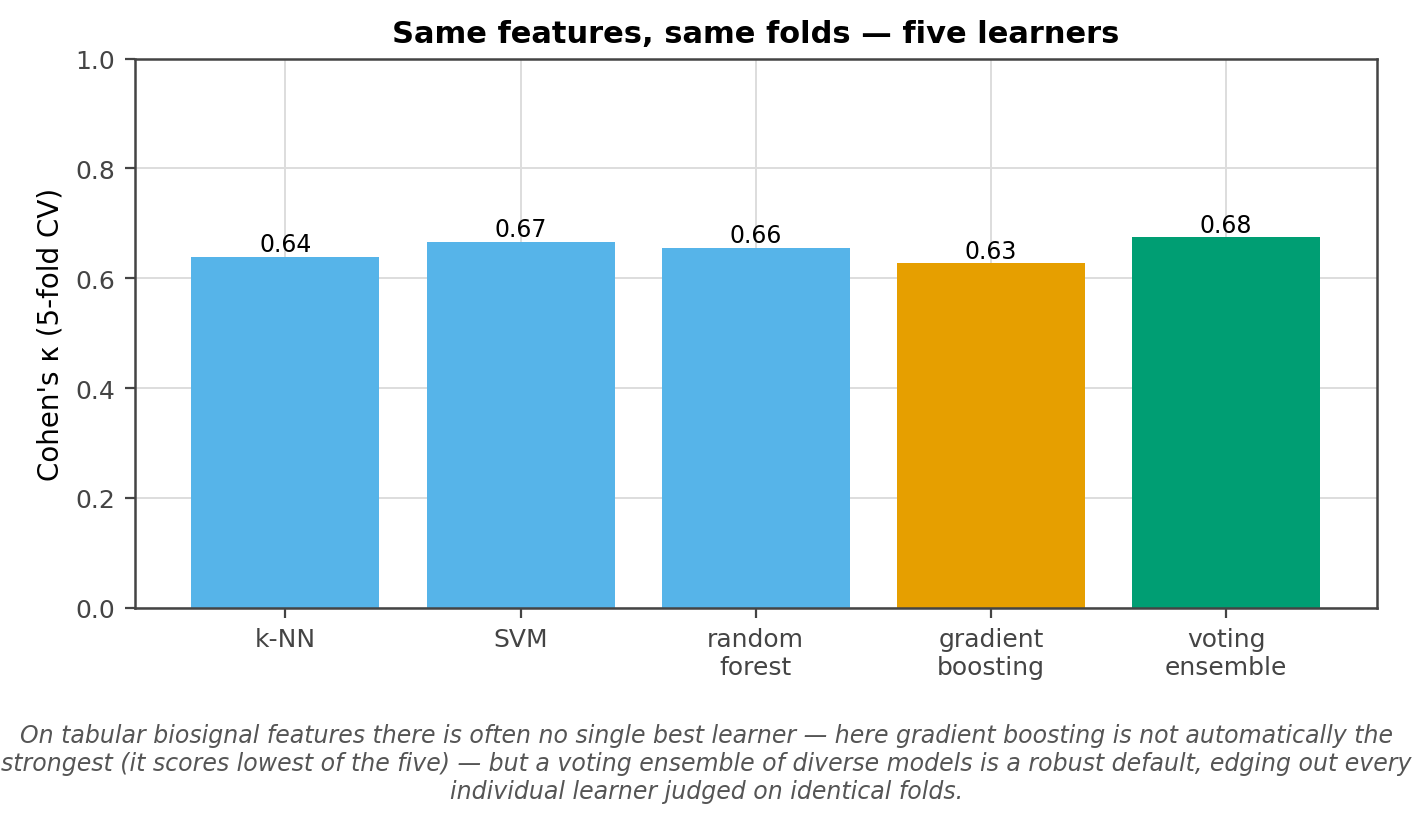

In [6]:
# A fair fight on identical folds — adding gradient boosting and a voting ensemble
# to the k-NN / SVM / random-forest trio of the chapter.
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import cohen_kappa_score
from sklearn.pipeline import make_pipeline
X, y = make_highd(seed=3)
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(7))
svm = make_pipeline(StandardScaler(), SVC(random_state=0))
rf = RandomForestClassifier(200, random_state=0)
gb = GradientBoostingClassifier(random_state=0)
vote = VotingClassifier([("knn", knn), ("svm", svm), ("rf", rf), ("gb", gb)], voting="hard")
models = [("k-NN", knn, bs.C["sky"]), ("SVM", svm, bs.C["sky"]),
          ("random\nforest", rf, bs.C["sky"]), ("gradient\nboosting", gb, bs.C["orange"]),
          ("voting\nensemble", vote, bs.C["green"])]
names, kappas, cols = [], [], []
for nm, m, c in models:
    yp = cross_val_predict(m, X, y, cv=5)
    names.append(nm); kappas.append(cohen_kappa_score(y, yp)); cols.append(c)
fig, ax = bs.newfig(w=7.0, h=3.6)
bars = ax.bar(names, kappas, color=cols)
for b, k in zip(bars, kappas):
    ax.text(b.get_x() + b.get_width() / 2, k + 0.01, f"{k:.2f}", ha="center", fontsize=8.5)
ax.set_ylabel("Cohen's κ (5-fold CV)"); ax.set_ylim(0, 1)
ax.set_title("Same features, same folds — five learners")
bs.takeaway(fig, "On tabular biosignal features there is often no single best learner — here gradient "
                 "boosting is not automatically the strongest (it scores lowest of the five) — but a "
                 "voting ensemble of diverse models is a robust default, edging out every individual "
                 "learner judged on identical folds.")
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above exactly. Change a parameter and watch them move — that loop between the page and the running code is where the intuition forms.

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> `fitcknn`, `fitcsvm`, `TreeBagger`, `kmeans`, `pca`.

## Leakage-safety checklist

Any ML step in this notebook must obey:

- no scaling or feature selection **before** the split;
- no epoch-level random split when claiming new-subject generalisation (use LOSO / GroupKFold);
- every reported metric states its split unit (epoch, subject, night);
- synthetic performance is labelled *illustrative*, never clinical.

In [7]:
from bsp.notebook_checks import assert_no_subject_leak
# Example guard used throughout the pipeline notebooks:
# assert_no_subject_leak(groups[train_idx], groups[test_idx])

## Sweep and defend — model capacity ↔ generalization

There is **no single best model complexity**. More capacity fits the training data better, but past a point the model *memorizes* and generalization falls. The cell sweeps a random forest's depth and **measures** training versus cross-validated accuracy.

**Spec to design against:** a small clinical dataset where you must generalize to new data. **Defend it:** which depth does your spec pick, and how do you *see* overfitting begin (the gap between the two curves)? Name a capacity choice that would be *wrong* for a small dataset, and why.

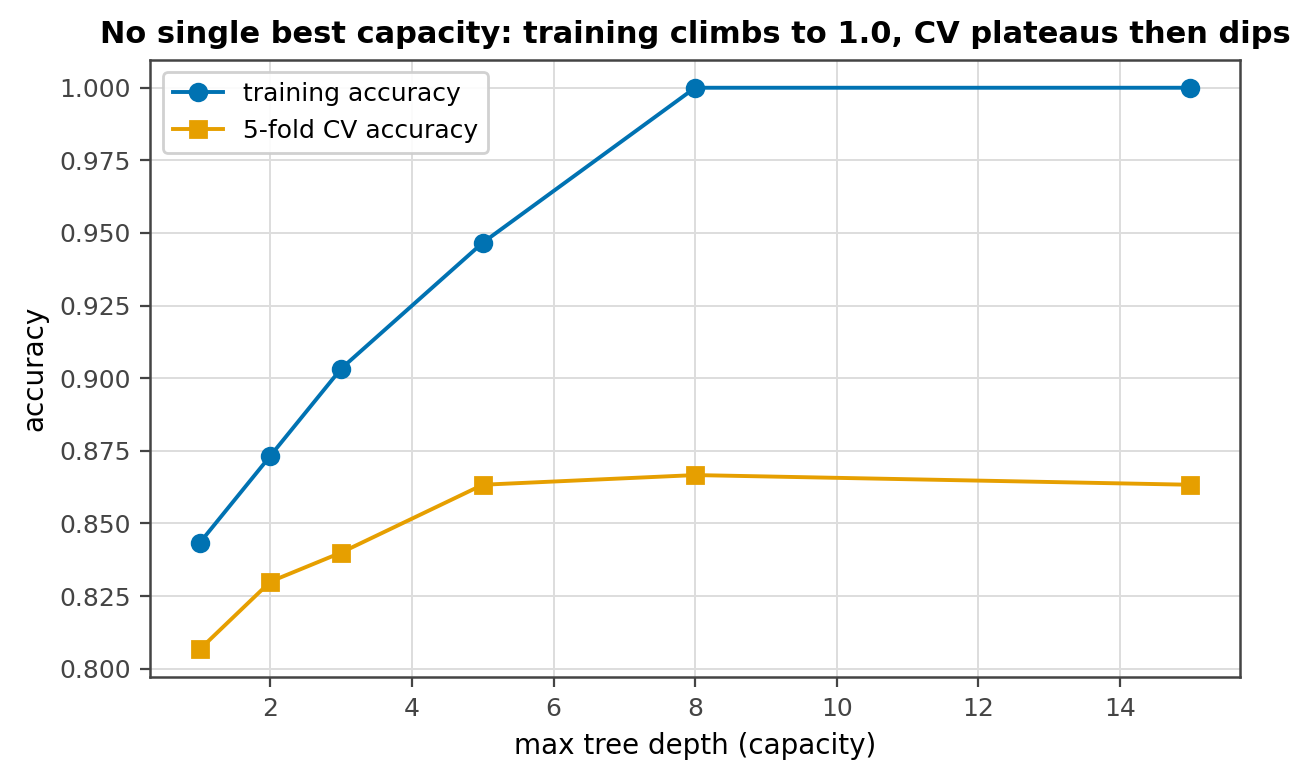

depths: [1, 2, 3, 5, 8, 15]
train : [0.84, 0.87, 0.9, 0.95, 1.0, 1.0]
cv    : [np.float64(0.81), np.float64(0.83), np.float64(0.84), np.float64(0.86), np.float64(0.87), np.float64(0.86)]


In [8]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=300, n_features=15, n_informative=5, n_redundant=2, random_state=0)
depths = [1, 2, 3, 5, 8, 15]; tr, cv = [], []
for d in depths:
    clf = RandomForestClassifier(150, max_depth=d, random_state=0).fit(X, y)
    tr.append(clf.score(X, y)); cv.append(cross_val_score(clf, X, y, cv=5).mean())
plt.figure(figsize=(6.4, 4))
plt.plot(depths, tr, 'o-', label='training accuracy')
plt.plot(depths, cv, 's-', label='5-fold CV accuracy')
plt.xlabel('max tree depth (capacity)'); plt.ylabel('accuracy'); plt.legend()
plt.title('No single best capacity: training climbs to 1.0, CV plateaus then dips')
plt.tight_layout(); plt.show()
print('depths:', depths); print('train :', [round(v, 2) for v in tr]); print('cv    :', [round(v, 2) for v in cv])

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Open Lab 13 (which has subject structure) and train k-NN, SVM and RF on the SAME GroupKFold/LOSO folds there, and compare kappa.

<details><summary>💡 Hint &amp; what you should see</summary>

The point is the **fair fight** — same split, same features, same metric. RF usually leads on tabular biosignal features, but the gaps are often smaller than the split-choice effect from Ch12.

</details>

**2.** Cluster epochs with k-means and overlay on the true stages.

<details><summary>💡 Hint &amp; what you should see</summary>

Unsupervised clusters partly align with stages (Wake/N3 separate well; N1 blurs) — structure exists without labels, but **clusters ≠ clinical classes**, and k won't rediscover exactly 5.

</details>

In [9]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch13_figures.py`.*